# Evaluating k-Means Clustering Across Different Dataset Structures

## Objectives
- Introduce k-Means clustering
- Demonstrate how the number of clusters (k) affects results
- Show when k-Means works well
- Show where k-Means struggles
- Compare clustering quality using visualisations and metrics

## Datasets used
1. Synthetic Blobs dataset
2. Synthetic Moons dataset
3. Iris dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42

# What is k-Means?

k-Means is an unsupervised learning algorithm that partitions data into **k clusters**.

## How it works
1. Choose the number of clusters, k
2. Randomly initialise k centroids
3. Assign each data point to the nearest centroid
4. Recalculate the centroid of each cluster
5. Repeat until the assignments stabilise

In [2]:
def standardize_data(X):
    scaler = StandardScaler()
    return scaler.fit_transform(X)


def fit_kmeans(X, k, n_init=20):
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=n_init
    )
    labels = model.fit_predict(X)
    return model, labels


def clustering_metrics(X, labels, true_labels=None):
    metrics = {}
    metrics["Inertia"] = None
    metrics["Silhouette Score"] = None
    metrics["Adjusted Rand Index"] = None

    unique_clusters = np.unique(labels)
    if len(unique_clusters) > 1 and len(unique_clusters) < len(X):
        metrics["Silhouette Score"] = silhouette_score(X, labels)

    if true_labels is not None:
        metrics["Adjusted Rand Index"] = adjusted_rand_score(true_labels, labels)

    return metrics


def evaluate_k_range(X, k_values, true_labels=None):
    rows = []

    for k in k_values:
        model, labels = fit_kmeans(X, k)
        row = {
            "k": k,
            "Inertia": model.inertia_,
            "Silhouette Score": np.nan,
            "Adjusted Rand Index": np.nan
        }

        if len(np.unique(labels)) > 1:
            row["Silhouette Score"] = silhouette_score(X, labels)

        if true_labels is not None:
            row["Adjusted Rand Index"] = adjusted_rand_score(true_labels, labels)

        rows.append(row)

    return pd.DataFrame(rows)


def plot_clusters_2d(X, labels, centroids=None, title="Cluster Plot", true_labels=None):
    plt.figure(figsize=(7, 5))
    plt.scatter(X[:, 0], X[:, 1], c=labels, edgecolors="k")
    if centroids is not None:
        plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=250, edgecolors="k")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


def plot_metric_lines(results_df, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(results_df["k"], results_df["Inertia"], marker="o")
    axes[0].set_title(f"{title_prefix}Elbow Plot")
    axes[0].set_xlabel("Number of clusters (k)")
    axes[0].set_ylabel("Inertia")
    axes[0].grid(True)

    axes[1].plot(results_df["k"], results_df["Silhouette Score"], marker="o")
    axes[1].set_title(f"{title_prefix}Silhouette Scores")
    axes[1].set_xlabel("Number of clusters (k)")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


def pca_transform(X, n_components=2):
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X)
    return X_pca, pca


def cluster_summary_table(X, labels):
    df = pd.DataFrame(X)
    df["cluster"] = labels
    summary = df.groupby("cluster").mean()
    return summary


def show_confusion_with_true_labels(true_labels, cluster_labels, title="True labels vs cluster labels"):
    cm = confusion_matrix(true_labels, cluster_labels)
    plt.figure(figsize=(6, 4))
    plt.imshow(cm, aspect="auto")
    plt.title(title)
    plt.xlabel("Predicted Cluster")
    plt.ylabel("True Label")
    plt.colorbar()
    plt.show()

In [3]:
# Blobs dataset
X_blobs, y_blobs = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=1.2,
    random_state=RANDOM_STATE
)

# Moons dataset
X_moons, y_moons = make_moons(
    n_samples=300,
    noise=0.10,
    random_state=RANDOM_STATE
)

# Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
iris_feature_names = iris.feature_names
iris_class_names = iris.target_names

# Standardize all datasets
X_blobs_scaled = standardize_data(X_blobs)
X_moons_scaled = standardize_data(X_moons)
X_iris_scaled = standardize_data(X_iris)

print("Blobs shape:", X_blobs_scaled.shape)
print("Moons shape:", X_moons_scaled.shape)
print("Iris shape:", X_iris_scaled.shape)

Blobs shape: (300, 2)
Moons shape: (300, 2)
Iris shape: (150, 4)


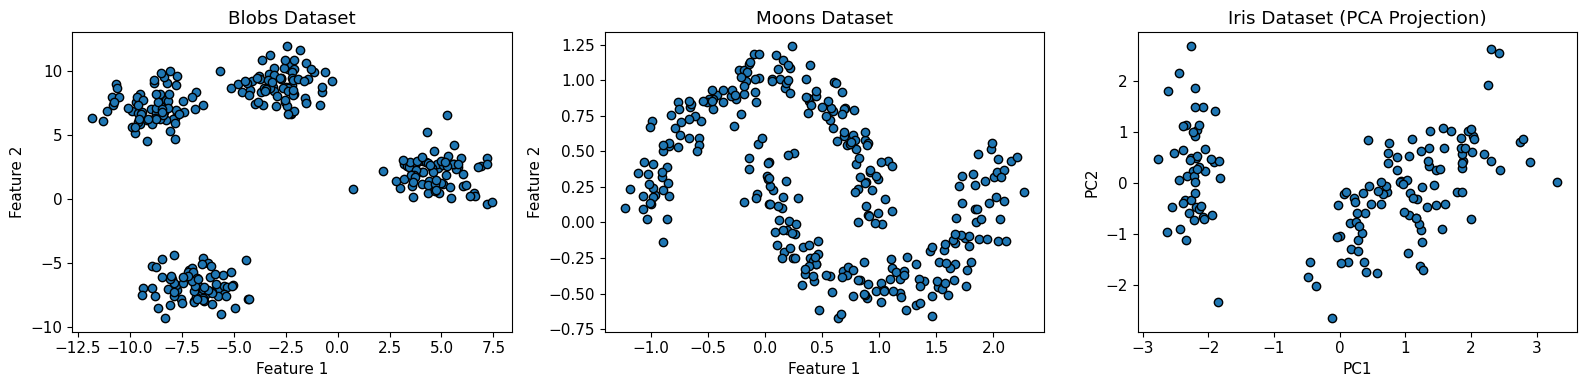

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], edgecolors="k")
axes[0].set_title("Blobs Dataset")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], edgecolors="k")
axes[1].set_title("Moons Dataset")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

X_iris_pca, iris_pca = pca_transform(X_iris_scaled, n_components=2)
axes[2].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], edgecolors="k")
axes[2].set_title("Iris Dataset (PCA Projection)")
axes[2].set_xlabel("PC1")
axes[2].set_ylabel("PC2")

plt.tight_layout()
plt.show()

# Part 1: Blobs Dataset

This dataset contains well-separated compact clusters, which is ideal for k-Means.

In [5]:
k_values = range(2, 8)

blobs_results = evaluate_k_range(X_blobs_scaled, k_values, true_labels=y_blobs)
blobs_results

,k,Inertia,Silhouette Score,Adjusted Rand Index
0,2,318.786128,0.545348,0.331096
1,3,77.772015,0.722714,0.712223
2,4,24.562913,0.758246,0.991081
3,5,21.972674,0.640878,0.905540
4,6,19.445299,0.528857,0.812310
5,7,17.275302,0.423284,0.706936


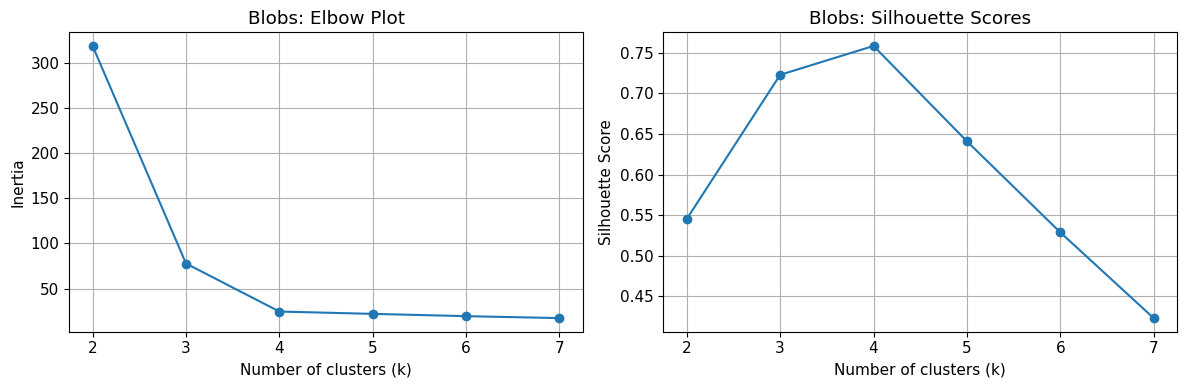

In [6]:
plot_metric_lines(blobs_results, title_prefix="Blobs: ")

In [7]:
best_k_blobs = int(blobs_results.loc[blobs_results["Silhouette Score"].idxmax(), "k"])
print("Best k for Blobs based on silhouette score:", best_k_blobs)

blobs_model, blobs_labels = fit_kmeans(X_blobs_scaled, best_k_blobs)
print("Inertia:", blobs_model.inertia_)
print("Silhouette Score:", silhouette_score(X_blobs_scaled, blobs_labels))
print("Adjusted Rand Index:", adjusted_rand_score(y_blobs, blobs_labels))

Best k for Blobs based on silhouette score: 4
Inertia: 24.56291318544907
Silhouette Score: 0.7582458926237312
Adjusted Rand Index: 0.9910811504997546


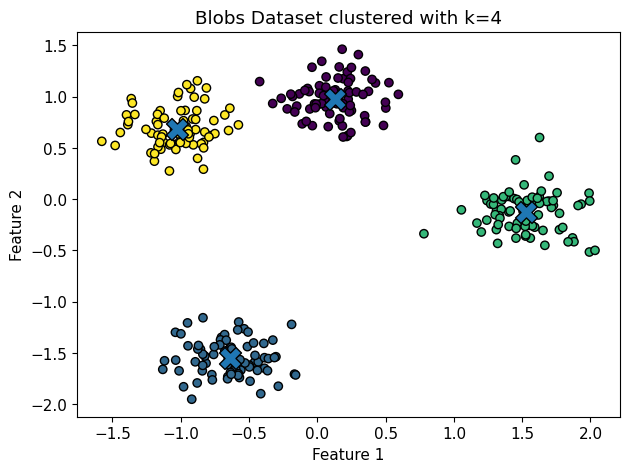

In [8]:
plot_clusters_2d(
    X_blobs_scaled,
    blobs_labels,
    centroids=blobs_model.cluster_centers_,
    title=f"Blobs Dataset clustered with k={best_k_blobs}"
)

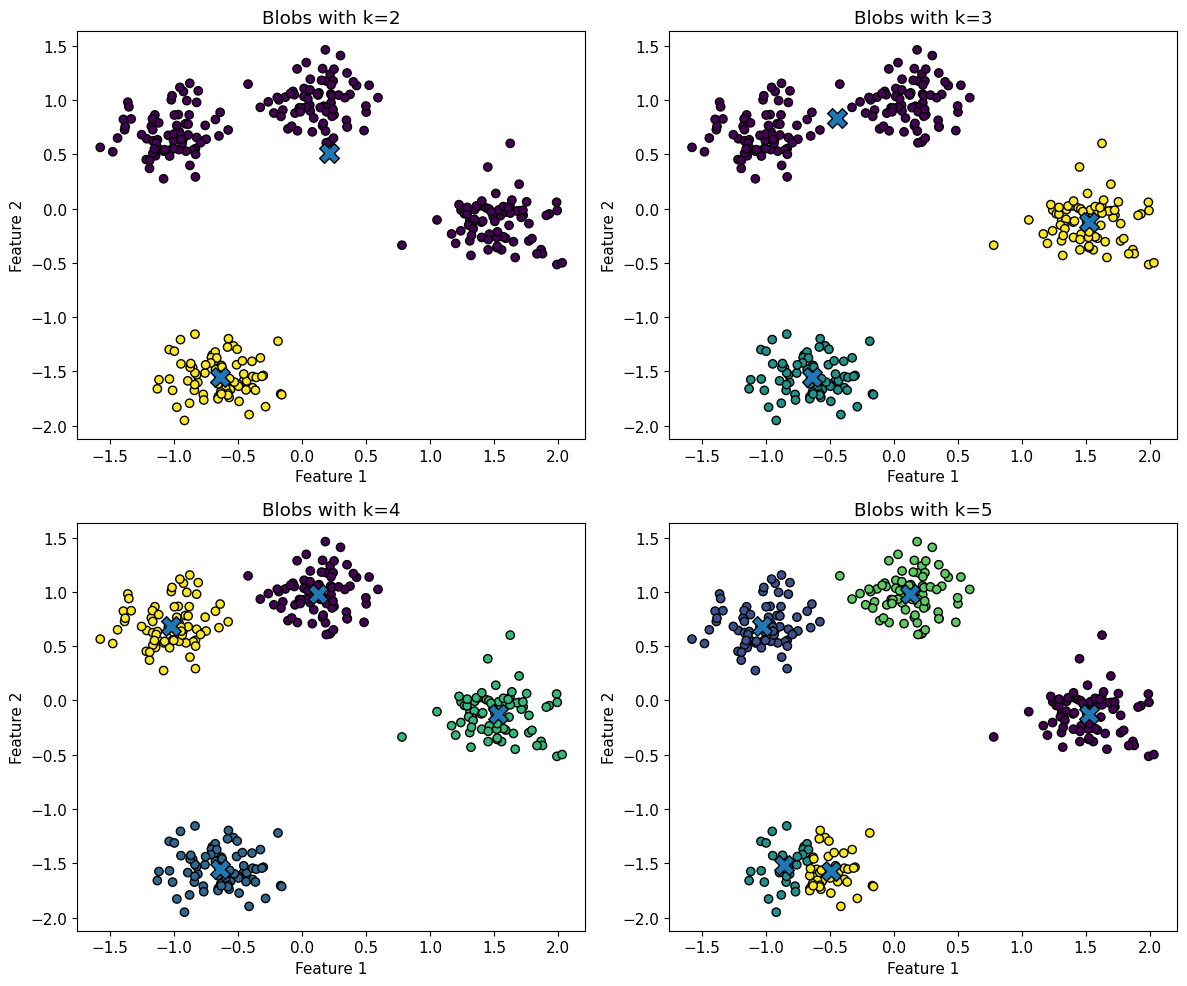

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, k in zip(axes.ravel(), [2, 3, 4, 5]):
    model, labels = fit_kmeans(X_blobs_scaled, k)
    ax.scatter(X_blobs_scaled[:, 0], X_blobs_scaled[:, 1], c=labels, edgecolors="k")
    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], marker="X", s=200, edgecolors="k")
    ax.set_title(f"Blobs with k={k}")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

# Part 2: Moons Dataset

This dataset has two curved clusters.

In [10]:
moons_results = evaluate_k_range(X_moons_scaled, k_values, true_labels=y_moons)
moons_results

,k,Inertia,Silhouette Score,Adjusted Rand Index
0,2,252.682584,0.490996,0.478969
1,3,188.914815,0.433007,0.382250
2,4,128.862592,0.409163,0.290097
3,5,95.073195,0.434819,0.294163
4,6,73.196009,0.444097,0.274829
5,7,60.709258,0.450495,0.266634


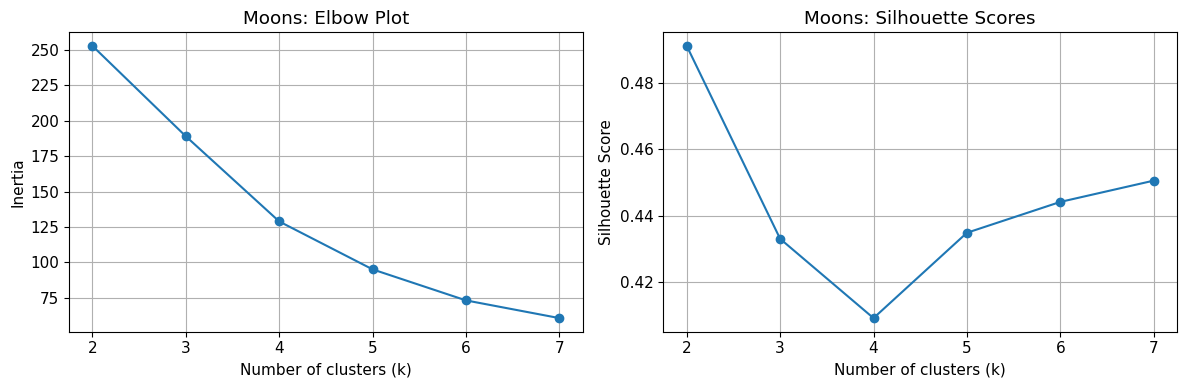

In [11]:
plot_metric_lines(moons_results, title_prefix="Moons: ")

In [12]:
moons_model, moons_labels = fit_kmeans(X_moons_scaled, 2)

print("Moons with k=2")
print("Inertia:", moons_model.inertia_)
print("Silhouette Score:", silhouette_score(X_moons_scaled, moons_labels))
print("Adjusted Rand Index:", adjusted_rand_score(y_moons, moons_labels))

Moons with k=2
Inertia: 252.68258395161052
Silhouette Score: 0.4909962103863311
Adjusted Rand Index: 0.47896853094705444


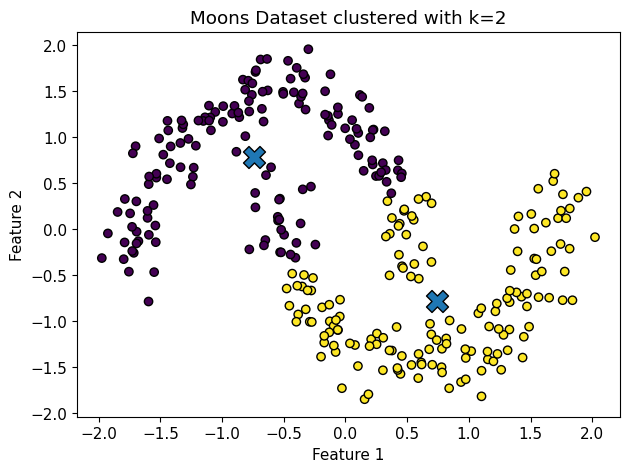

In [13]:
plot_clusters_2d(
    X_moons_scaled,
    moons_labels,
    centroids=moons_model.cluster_centers_,
    title="Moons Dataset clustered with k=2"
)

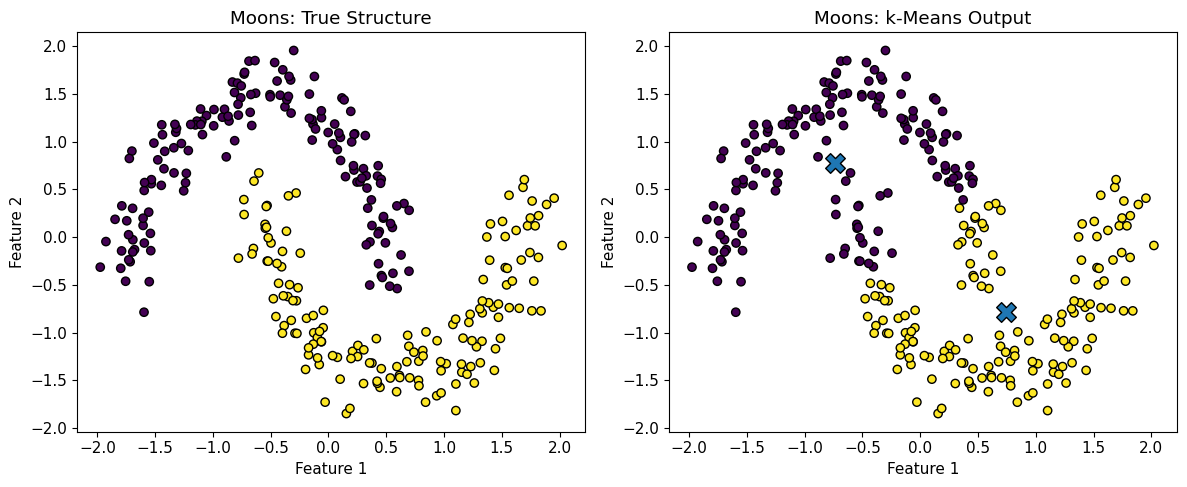

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=y_moons, edgecolors="k")
axes[0].set_title("Moons: True Structure")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=moons_labels, edgecolors="k")
axes[1].scatter(moons_model.cluster_centers_[:, 0], moons_model.cluster_centers_[:, 1], marker="X", s=200, edgecolors="k")
axes[1].set_title("Moons: k-Means Output")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

# Part 3: Iris Dataset

The Iris dataset is a real multiclass dataset with four features.

In [15]:
iris_results = evaluate_k_range(X_iris_scaled, k_values, true_labels=y_iris)
iris_results

,k,Inertia,Silhouette Score,Adjusted Rand Index
0,2,222.361705,0.581750,0.568116
1,3,139.820496,0.459948,0.620135
2,4,114.092328,0.384471,0.470818
3,5,90.807592,0.345511,0.420481
4,6,80.022188,0.322037,0.353814
5,7,71.033431,0.327694,0.320391


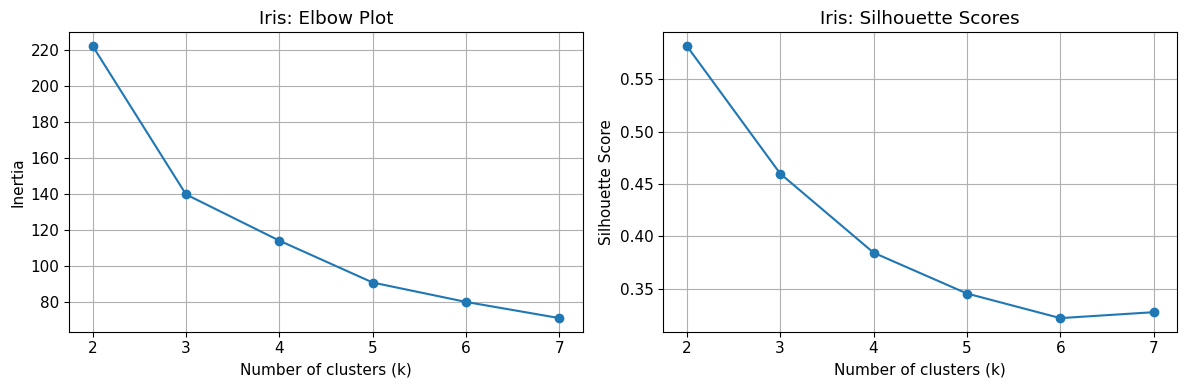

In [16]:
plot_metric_lines(iris_results, title_prefix="Iris: ")

In [17]:
iris_model, iris_labels = fit_kmeans(X_iris_scaled, 3)

print("Iris with k=3")
print("Inertia:", iris_model.inertia_)
print("Silhouette Score:", silhouette_score(X_iris_scaled, iris_labels))
print("Adjusted Rand Index:", adjusted_rand_score(y_iris, iris_labels))

Iris with k=3
Inertia: 139.82049635974982
Silhouette Score: 0.45994823920518635
Adjusted Rand Index: 0.6201351808870379


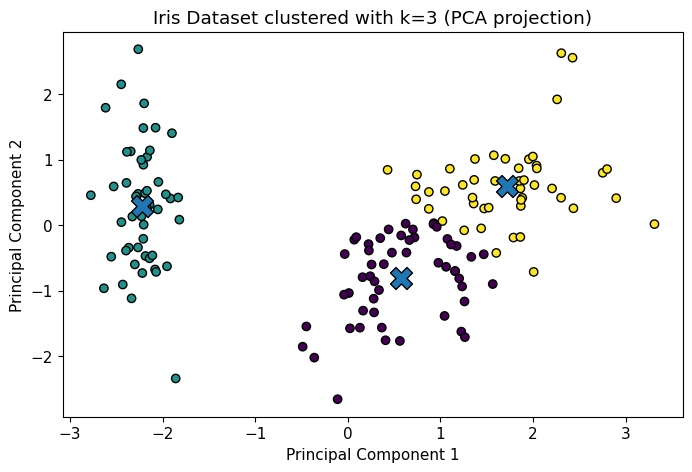

In [18]:
X_iris_pca, iris_pca = pca_transform(X_iris_scaled, n_components=2)
iris_centroids_pca = iris_pca.transform(iris_model.cluster_centers_)

plt.figure(figsize=(8, 5))
plt.scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=iris_labels, edgecolors="k")
plt.scatter(iris_centroids_pca[:, 0], iris_centroids_pca[:, 1], marker="X", s=250, edgecolors="k")
plt.title("Iris Dataset clustered with k=3 (PCA projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

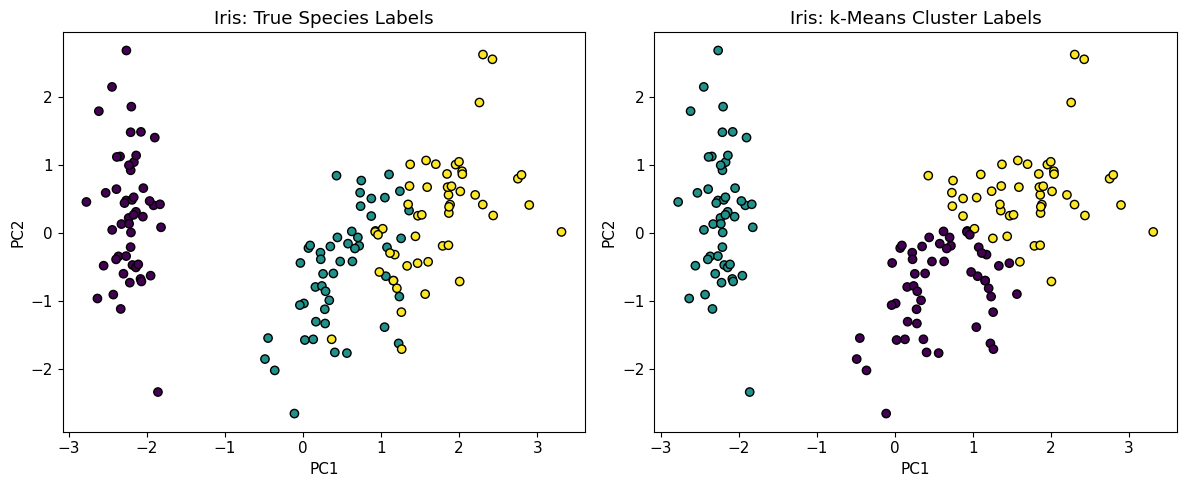

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=y_iris, edgecolors="k")
axes[0].set_title("Iris: True Species Labels")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=iris_labels, edgecolors="k")
axes[1].set_title("Iris: k-Means Cluster Labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [20]:
iris_df = pd.DataFrame(X_iris, columns=iris_feature_names)
iris_df["True Label"] = y_iris
iris_df["Predicted Cluster"] = iris_labels

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),True Label,Predicted Cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


In [21]:
iris_df = pd.DataFrame(X_iris, columns=iris_feature_names)
iris_df["True Label"] = y_iris
iris_df["Predicted Cluster"] = iris_labels

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),True Label,Predicted Cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


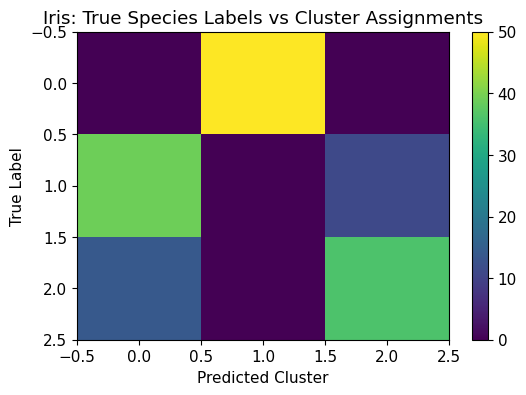

In [22]:
show_confusion_with_true_labels(
    y_iris,
    iris_labels,
    title="Iris: True Species Labels vs Cluster Assignments"
)

In [23]:
comparison_df = pd.DataFrame([
    {
        "Dataset": "Blobs",
        "Chosen k": best_k_blobs,
        "Inertia": blobs_model.inertia_,
        "Silhouette Score": silhouette_score(X_blobs_scaled, blobs_labels),
        "Adjusted Rand Index": adjusted_rand_score(y_blobs, blobs_labels)
    },
    {
        "Dataset": "Moons",
        "Chosen k": 2,
        "Inertia": moons_model.inertia_,
        "Silhouette Score": silhouette_score(X_moons_scaled, moons_labels),
        "Adjusted Rand Index": adjusted_rand_score(y_moons, moons_labels)
    },
    {
        "Dataset": "Iris",
        "Chosen k": 3,
        "Inertia": iris_model.inertia_,
        "Silhouette Score": silhouette_score(X_iris_scaled, iris_labels),
        "Adjusted Rand Index": adjusted_rand_score(y_iris, iris_labels)
    }
])

comparison_df

,Dataset,Chosen k,Inertia,Silhouette Score,Adjusted Rand Index
0,Blobs,4,24.562913,0.758246,0.991081
1,Moons,2,252.682584,0.490996,0.478969
2,Iris,3,139.820496,0.459948,0.620135


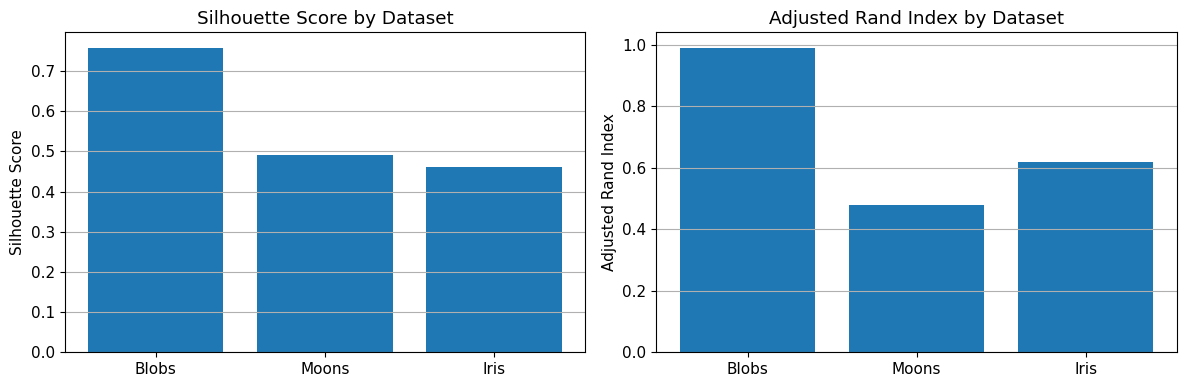

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(comparison_df["Dataset"], comparison_df["Silhouette Score"])
axes[0].set_title("Silhouette Score by Dataset")
axes[0].set_ylabel("Silhouette Score")
axes[0].grid(axis="y")

axes[1].bar(comparison_df["Dataset"], comparison_df["Adjusted Rand Index"])
axes[1].set_title("Adjusted Rand Index by Dataset")
axes[1].set_ylabel("Adjusted Rand Index")
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

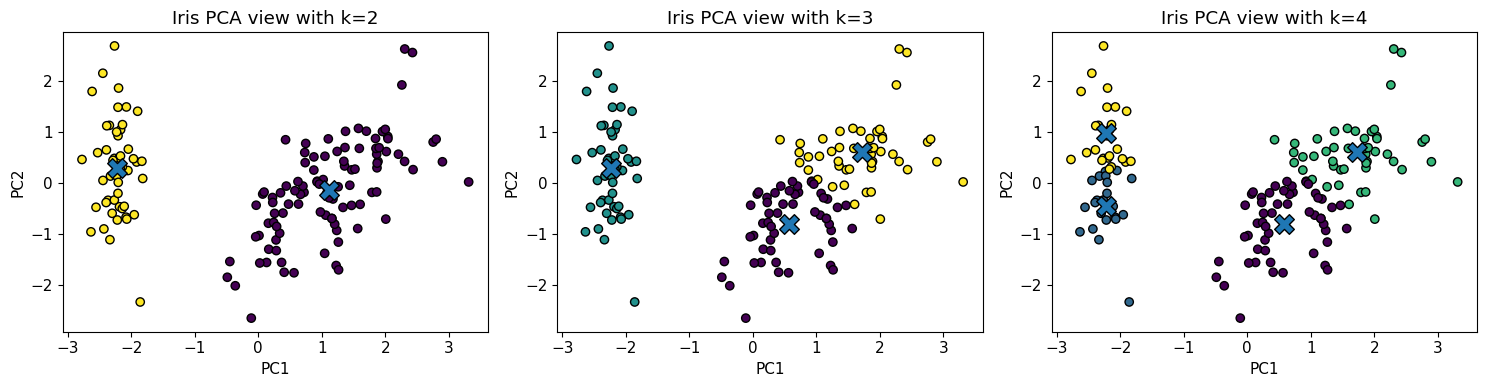

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, k in zip(axes, [2, 3, 4]):
    model, labels = fit_kmeans(X_iris_scaled, k)
    centroids_pca = iris_pca.transform(model.cluster_centers_)
    
    ax.scatter(X_iris_pca[:, 0], X_iris_pca[:, 1], c=labels, edgecolors="k")
    ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker="X", s=200, edgecolors="k")
    ax.set_title(f"Iris PCA view with k={k}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

In [26]:
summary_table = pd.concat([
    blobs_results.assign(Dataset="Blobs"),
    moons_results.assign(Dataset="Moons"),
    iris_results.assign(Dataset="Iris")
], ignore_index=True)

summary_table = summary_table[["Dataset", "k", "Inertia", "Silhouette Score", "Adjusted Rand Index"]]
summary_table

,Dataset,k,Inertia,Silhouette Score,Adjusted Rand Index
0,Blobs,2,318.786128,0.545348,0.331096
1,Blobs,3,77.772015,0.722714,0.712223
2,Blobs,4,24.562913,0.758246,0.991081
3,Blobs,5,21.972674,0.640878,0.905540
4,Blobs,6,19.445299,0.528857,0.812310
5,Blobs,7,17.275302,0.423284,0.706936
6,Moons,2,252.682584,0.490996,0.478969
7,Moons,3,188.914815,0.433007,0.382250
8,Moons,4,128.862592,0.409163,0.290097
9,Moons,5,95.073195,0.434819,0.294163
